# Perceptrón con Dos Entradas
## Conversión desde MATLAB a Python

Este notebook explica paso a paso el funcionamiento del **Perceptrón** con dos entradas.

Incluye:
- Fundamento matemático
- Implementación desde cero
- Animación del proceso de aprendizaje
- Animación de la frontera de decisión
- Animación del vector de pesos W (perpendicular a la frontera)


## 1️⃣ Modelo Matemático

El perceptrón calcula:

$$ y = f(W^T x + b) $$

Donde:
- $W = [w_1, w_2]$ es el vector de pesos
- $x = [x_1, x_2]$ es el vector de entrada
- $b$ es el bias
- $f(.)$ es la función escalón:

$$
f(n) = \begin{cases}
1 & n \ge 0 \\
0 & n < 0
\end{cases}
$$

La frontera de decisión está dada por:

$$ W^T x + b = 0 $$

El vector **W** es perpendicular a la recta de decisión.


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
from IPython.display import HTML


# Datos (mismo ejemplo MATLAB)
P = np.array([[1, 2],
              [-1, 2],
              [0, -1]])

t = np.array([1, 0, 0])

# Inicialización
W = np.zeros(2)
b = 0
lr = 0.5

W_history = []
b_history = []

# Entrenamiento
for epoch in range(20):
    error_total = 0
    for i in range(len(P)):
        x = P[i]
        target = t[i]
        n = np.dot(W, x) + b
        y = 1 if n >= 0 else 0
        e = target - y

        W = W + lr * e * x
        b = b + lr * e

        error_total += abs(e)
        W_history.append(W.copy())
        b_history.append(b)
    if error_total == 0:
        break

print('Pesos finales:', W)
print('Bias final:', b)


Pesos finales: [1.  0.5]
Bias final: -0.5


## 2️⃣ Animación del Aprendizaje

- La línea representa la frontera de decisión.
- La flecha roja es el vector de pesos W.
- W es perpendicular a la recta.


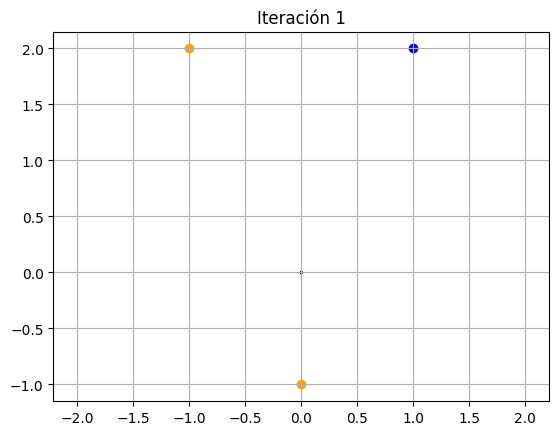

In [16]:
fig, ax = plt.subplots()

def update(frame):
    ax.clear()
    W = W_history[frame]
    b = b_history[frame]

    # Graficar puntos
    for i in range(len(P)):
        if t[i] == 1:
            ax.scatter(P[i,0], P[i,1], c='blue')
        else:
            ax.scatter(P[i,0], P[i,1], c='orange')

    # Frontera de decisión
    x_vals = np.linspace(-3, 3, 100)
    if W[1] != 0:
        y_vals = -(W[0]*x_vals + b)/W[1]
        ax.plot(x_vals, y_vals)

    # Vector W (perpendicular)
    ax.quiver(0, 0, W[0], W[1], angles='xy', scale_units='xy', scale=1)

    ax.set_xlim(-3,3)
    ax.set_ylim(-3,3)
    ax.set_title(f"Iteración {frame+1}")
    ax.grid(True)
    plt.axis('equal')
# Assign the animation to a variable 'anim'
#anim = animation.FuncAnimation(fig, update_function, frames=..., interval=...)

ani = FuncAnimation(fig, update, frames=len(W_history), interval=500)
ani.save("Perceptron_Animacion.gif",
         writer="pillow",
         fps=5)
HTML(ani.to_jshtml())

#plt.show()


## 3️⃣ Conclusiones

- El perceptrón converge porque los datos son linealmente separables.
- El vector W define la orientación de la recta.
- El bias desplaza la recta.
- La frontera siempre es perpendicular al vector W.
